In [ ]:
#pip install tensorflow pandas numpy matplotlib scikit-learn


In [10]:
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.stattools import acf, q_stat
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

In [30]:

# Load the dataset
file_path = 'acm_ts.csv'  # Replace with your file path
data = pd.read_csv(file_path)

# Preprocessing the data
# Convert the 'Reporting Period' column to datetime and sort
data['Reporting Period'] = pd.to_datetime(data['Reporting Period'], format='%Y %b')
data = data.sort_values(by='Reporting Period')

# Use only the 'Value' column for forecasting
values = data['Value'].values.reshape(-1, 1)

# Normalize the values
scaler = MinMaxScaler(feature_range=(0, 1))
values_scaled = scaler.fit_transform(values)

# Define a function to create sequences for LSTM
def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

# Create train-test split (80-20), ensuring no missing rows
time_steps = 12
train_size = int(len(values_scaled) * 0.8)

# Include the last `time_steps` rows of training in test
train = values_scaled[:train_size]
test = values_scaled[train_size - time_steps:]

# Create sequences
X_train, y_train = create_sequences(train, time_steps)
X_test, y_test = create_sequences(test, time_steps)

# Print the shapes to confirm correctness
print(f"Dataset size: {len(values_scaled)}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Dataset size: 130
X_train shape: (92, 12, 1), y_train shape: (92, 1)
X_test shape: (26, 12, 1), y_test shape: (26, 1)


In [31]:


# Build the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_steps, 1)),
    LSTM(50, return_sequences=False),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

C:\Users\minli\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
# Train the model
model.fit(X_train, y_train, batch_size=1, epochs=50, verbose=0)

# Predict values
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse scale the predictions and actual values
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_inv = scaler.inverse_transform(y_train)
y_test_inv = scaler.inverse_transform(y_test)

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/stepWARNING:tensorflow:6 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000020C8DE29580> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


In [43]:
print(f"Shape of test_index: {len(test_index)}")
print(f"Shape of test_predict: {test_predict.shape[0]}")


Shape of test_index: 14
Shape of test_predict: 26


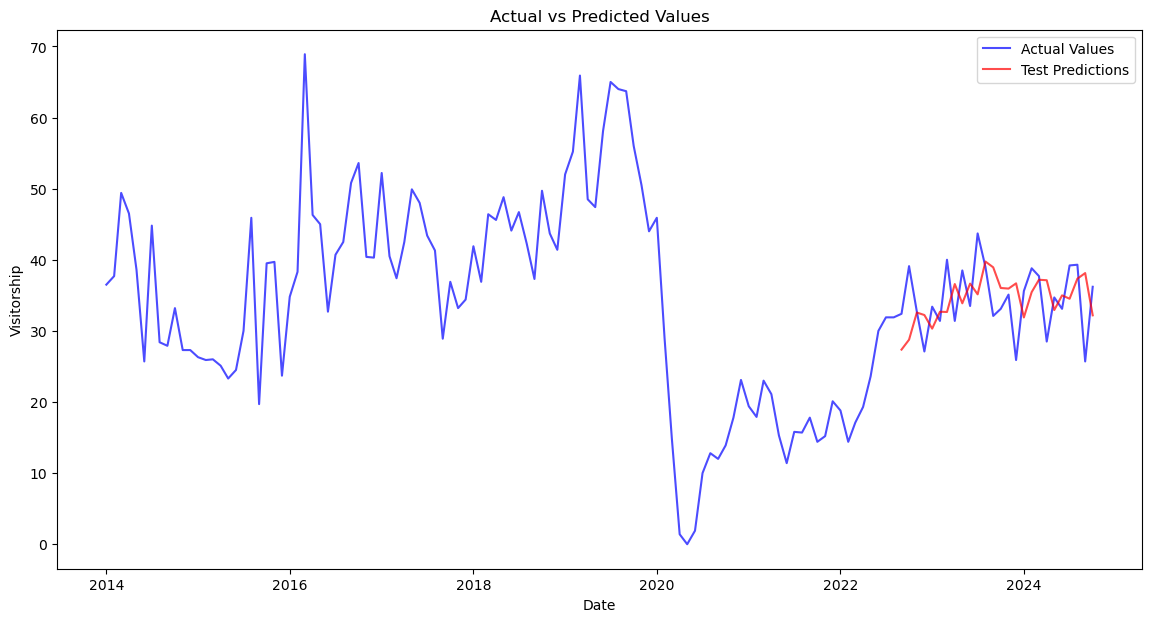

In [55]:
# Adjust the train and test indices for plotting
train_index = data['Reporting Period'][time_steps:train_size]
test_index = data['Reporting Period'][train_size:train_size + len(test_predict)]

# Visualize actual vs predicted values
plt.figure(figsize=(14, 7))

# Plot actual values
plt.plot(data['Reporting Period'], values, label='Actual Values', color='blue', alpha=0.7)

# Plot train predictions
#plt.plot(train_index, train_predict.flatten(), label='Train Predictions', color='green', alpha=0.7)

# Plot test predictions
plt.plot(test_index, test_predict.flatten(), label='Test Predictions', color='red', alpha=0.7)

plt.xlabel('Date')
plt.ylabel('Visitorship')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()


In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Compute RMSE and MAPE
train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict))
train_mape = mean_absolute_percentage_error(y_train_inv, train_predict) * 100
test_mape = mean_absolute_percentage_error(y_test_inv, test_predict) * 100

print(f"Train RMSE: {train_rmse:.2f}, Train MAPE: {train_mape:.2f}%")
print(f"Test RMSE: {test_rmse:.2f}, Test MAPE: {test_mape:.2f}%")


Train RMSE: 7.52, Train MAPE: 39294034888223192.00%
Test RMSE: 5.65, Test MAPE: 14.02%


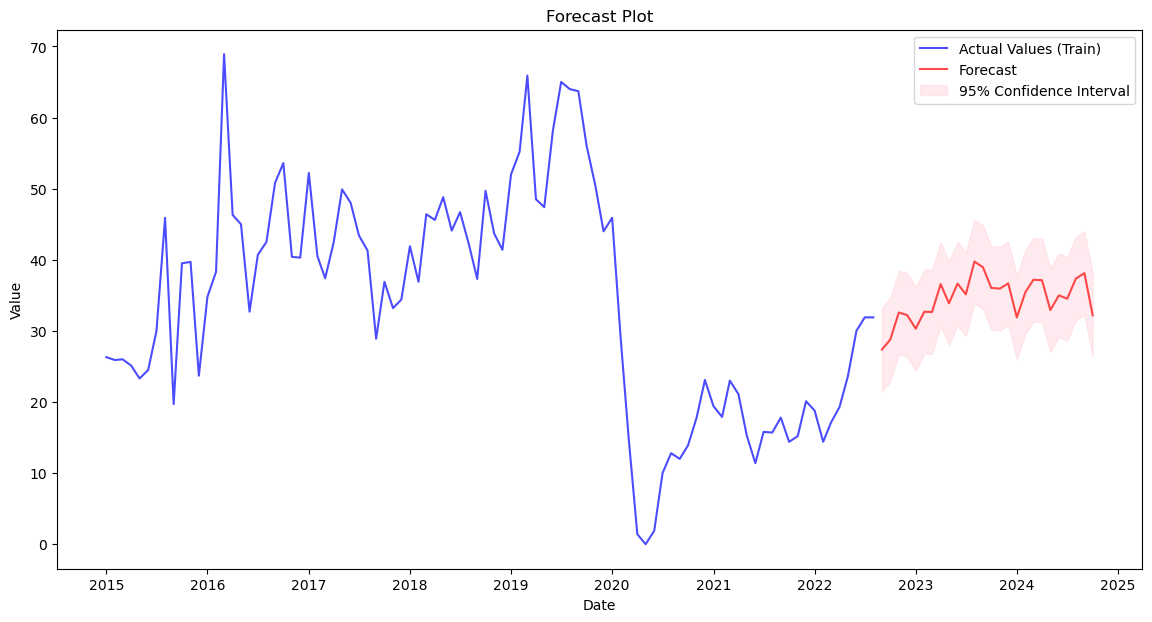

In [52]:
# Indices for training data
train_index = data['Reporting Period'][time_steps:train_size]

# Indices for forecasted data
forecast_index = data['Reporting Period'][train_size:train_size + len(test_predict)]

# Lower and upper bounds for confidence intervals
lower_bound = test_predict.flatten() - 1.96 * np.std(test_predict)
upper_bound = test_predict.flatten() + 1.96 * np.std(test_predict)

# Plot
plt.figure(figsize=(14, 7))

# Plot actual values for training data only
plt.plot(train_index, scaler.inverse_transform(values_scaled[:train_size][time_steps:]), label='Actual Values (Train)', color='blue', alpha=0.7)

# Plot forecast (test predictions)
plt.plot(forecast_index, test_predict.flatten(), label='Forecast', color='red', alpha=0.7)

# Optionally, add confidence intervals
plt.fill_between(forecast_index, lower_bound, upper_bound, color='pink', alpha=0.3, label='95% Confidence Interval')

plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Forecast Plot')
plt.legend()
plt.show()


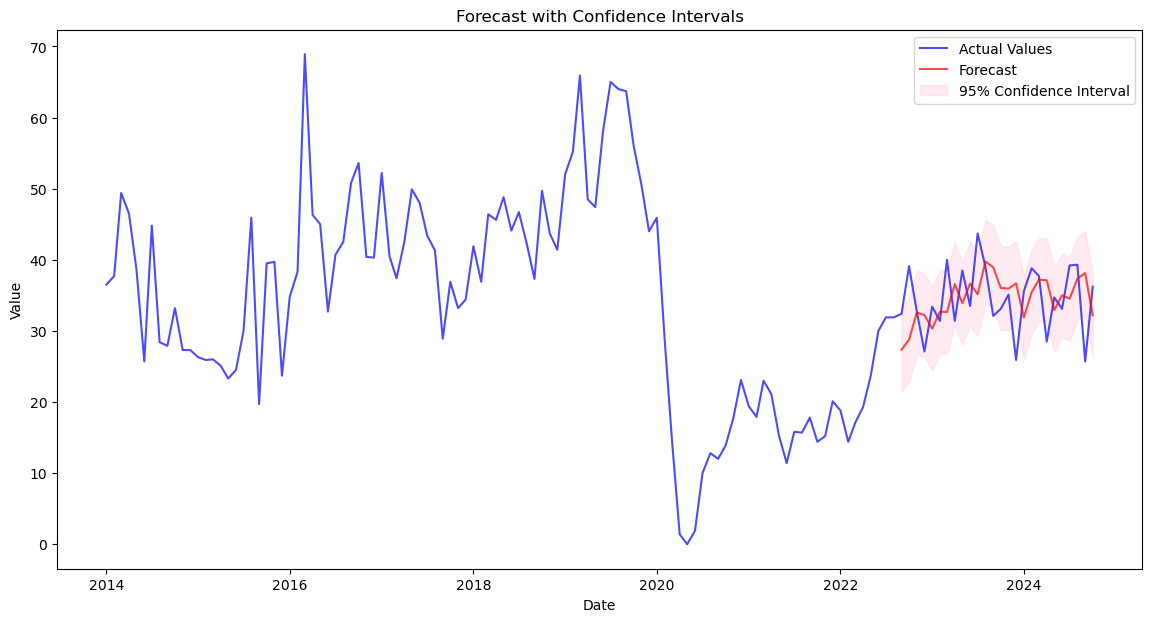

Box-Ljung Test:
Q-statistic: 13.94, p-value: 0.3778
The residuals appear random (no significant autocorrelation).


In [51]:
# Forecast plot with confidence intervals
#forecast_index = data['Reporting Period'][train_size + time_steps:]
lower_bound = test_predict.flatten() - 1.96 * np.std(test_predict)
upper_bound = test_predict.flatten() + 1.96 * np.std(test_predict)

plt.figure(figsize=(14, 7))
plt.plot(data['Reporting Period'], values, label='Actual Values', color='blue', alpha=0.7)
plt.plot(forecast_index, test_predict.flatten(), label='Forecast', color='red', alpha=0.7)
plt.fill_between(forecast_index, lower_bound, upper_bound, color='pink', alpha=0.3, label='95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Forecast with Confidence Intervals')
plt.legend()
plt.show()


# Box-Ljung Test
q_stat_val, p_val = q_stat(acf_values[1:], len(residuals))
print("Box-Ljung Test:")
print(f"Q-statistic: {q_stat_val[-1]:.2f}, p-value: {p_val[-1]:.4f}")

if p_val[-1] < 0.05:
    print("The residuals are not random (significant autocorrelation exists).")
else:
    print("The residuals appear random (no significant autocorrelation).")

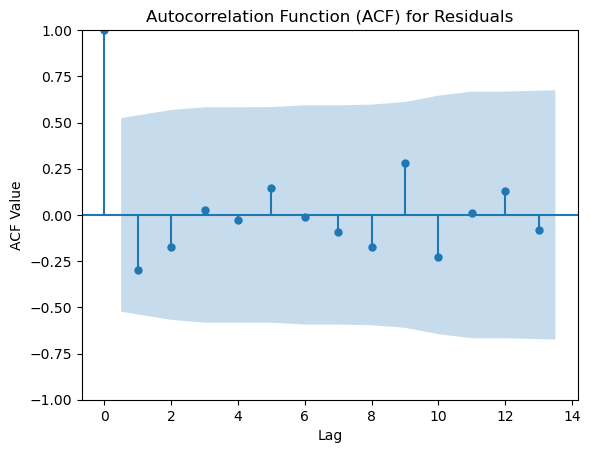

In [53]:
from statsmodels.graphics.tsaplots import plot_acf

# Adjust the max_lags to be at most the length of residuals
max_lags = min(20, len(residuals) - 1)

# ACF plot for residuals
acf_plot = plot_acf(residuals, lags=max_lags)
plt.title('Autocorrelation Function (ACF) for Residuals')
plt.xlabel('Lag')
plt.ylabel('ACF Value')
plt.show()


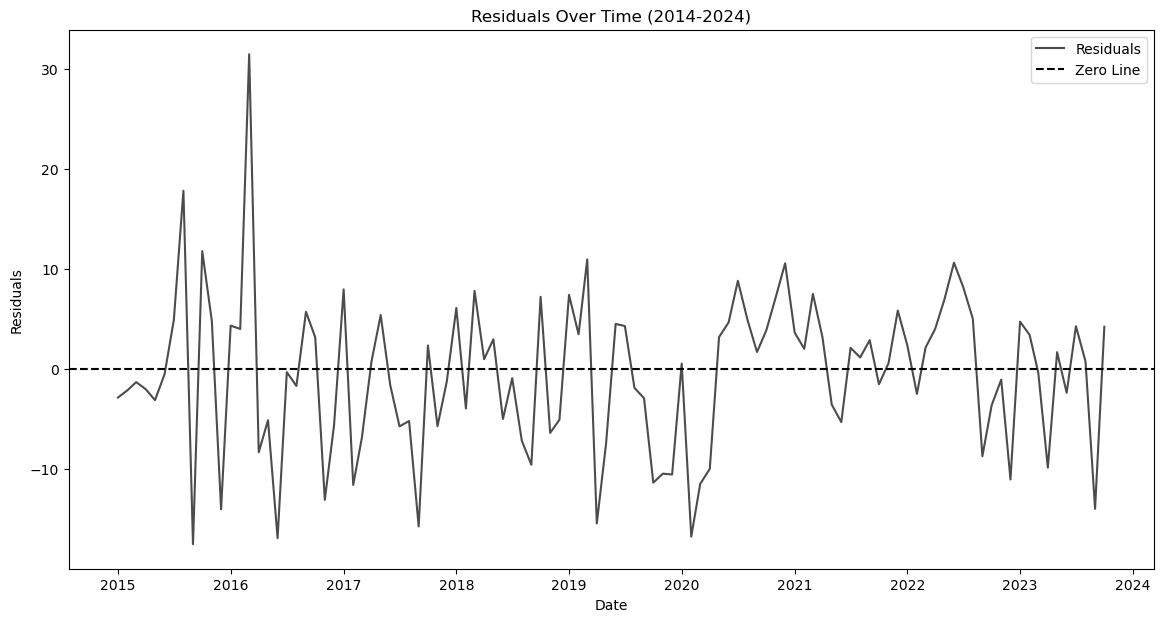

In [54]:
# Align residuals with the corresponding timeline
residuals_full = np.concatenate([train_residuals, test_residuals])
residuals_timeline = data['Reporting Period'][time_steps:time_steps + len(residuals_full)]

# Line plot of residuals
plt.figure(figsize=(14, 7))
plt.plot(residuals_timeline, residuals_full, label='Residuals', color='black', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', label='Zero Line')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.title('Residuals Over Time (2014-2024)')
plt.legend()
plt.show()

# higher variance at the start, lower towards the end?

In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

# Parameters for rolling forecast
time_steps = 12  # Length of input sequences
test_size = 12  # Number of timesteps to forecast in each fold
n_splits = len(data) - time_steps - test_size + 1  # Number of rolling iterations

# Store results
rmse_scores = []
mape_scores = []

for i in range(n_splits):
    # Define train and test sets
    train_end = time_steps + i
    test_start = train_end
    test_end = test_start + test_size
    
    train = values_scaled[:train_end]
    test = values_scaled[test_start:test_end]
    
    # Create sequences for training and testing
    X_train, y_train = create_sequences(train, time_steps)
    X_test, y_test = create_sequences(test, time_steps)
    
    # Train the model
    model.fit(X_train, y_train, batch_size=1, epochs=10, verbose=0)
    
    # Make predictions
    test_predict = model.predict(X_test)
    
    # Inverse transform predictions and actual values
    test_predict_inv = scaler.inverse_transform(test_predict)
    y_test_inv = scaler.inverse_transform(y_test)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict_inv))
    mape = mean_absolute_percentage_error(y_test_inv, test_predict_inv) * 100
    
    rmse_scores.append(rmse)
    mape_scores.append(mape)

# Print average scores
print(f"Average RMSE: {np.mean(rmse_scores):.2f}")
print(f"Average MAPE: {np.mean(mape_scores):.2f}%")


ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=True
  • mask=None